# HarvestStat Data Profiling - Malawi

In [1]:
import glob
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import numpy as np
import pandas as pd
import geopandas as gpd
from tools import retreive_fdw_data, save_npz, PrintAdminUnits, PlotAdminShapes
from tools import FDW_PD_Sweeper, FDW_PD_AvalTable, FDW_PD_Compiling, FDW_PD_ValidateFnidName
from tools import FDW_PD_CreateAdminLink, FDW_PD_RatioAdminLink, FDW_PD_ConnectAdminLink
from tools import product_name_mapping, FDW_PD_CaliSeasonYear, FDW_PD_MergeCropProductionSystem
from tools_graphic import PlotBarProduction, PlotLinePAY
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
pd.options.mode.chained_assignment = None

In [2]:
# Set loading parameters ------------------------ #
country_name = 'Malawi'
country_iso2 = 'MW'
use_api_data = True
requires_authentication = False
# ----------------------------------------------- #

# Load FEWS NET administrative boundaries ------- #
epsg = 'EPSG:32736' # Malawi
fn_shapes = sorted(glob.glob(f"../data/shapefile/fewsnet/{country_iso2}_Admin?_????.shp"))
shape_all = []
for fn in fn_shapes:
    name = fn[-18:-4]
    exec('%s = gpd.read_file("%s").to_crs("%s")' % (name, fn, epsg))
    exec('%s["area"] = %s["geometry"].area/10**6' % (name, name))
    exec('shape_all.append(%s)' % (name))
shape_all = pd.concat(shape_all, axis=0).reset_index(drop=True)
# PrintAdminUnits(shape_all)
# ----------------------------------------------- #

# Load FDW data -------------------------------- #
df = retreive_fdw_data(country_name, country_iso2, use_api_data, requires_authentication)
# ----------------------------------------------- #

Data is retrieved from the FDW API.
../data/crop_raw_data/adm_crop_data_raw_MW.csv is saved.


In [3]:
# Manual Pre-processing before Sweeping --------- #

# 1. Default setting 
# a) None-type crop production system
df.loc[df['crop_production_system'].isna(), 'crop_production_system'] = 'none'
df.loc[df['crop_production_system'] == '', 'crop_production_system'] = 'none'
# b) None-type population group
df.loc[df['population_group'].isna(), 'population_group'] = 'none'
df.loc[df['population_group'] == '', 'population_group'] = 'none'

# 2. Manual setting
# a) Add admin names to reporting units
admin_level = 'admin_3'
reporting_unit = df.loc[df['fnid'].map(lambda x: x[6] != 'A'), 'fnid'].unique()
df.loc[df.fnid.isin(reporting_unit),admin_level] = df.loc[df.fnid.isin(reporting_unit), 'locality_name'].map(lambda x: x.split(' ')[0])

# b) remove minor crops for which there is only a few years of data
df = df.loc[~(np.isin(df['product'],['Pineapple (unspecified)', 'Pigeon pea (hybrid)', 'Papaya (unspecified)', 
                                    'Orange (unspecified)', 'Mango (unspecified)', 'Macadamia (unspecified)']))]

#c) remove the "estate" and "Estate (PS)" production systems
df = df.loc[~(np.isin(df['crop_production_system'],['Estate (PS)','estate']))]

#d) rename crops
df.loc[(df['product']=='Pigeon pea (Unspecified)'),'product'] = 'Pigeon Peas'
df.loc[(df['product']=='Coffee (unspecified)'),'product'] = 'Coffee (Unspecified)'

#e) drop seasons that are not the main season with only intermediate amounts of data
df = df.loc[~((df['product']=='Rice (Paddy)')&(df['season_name']=='Winter'))]
df = df.loc[~((df['product']=='Bambara groundnut')&(df['season_name']=='Winter'))]
df = df.loc[~((df['product']=='Cassava')&(df['season_name']=='Winter'))]
df = df.loc[~((df['product']=='Sesame Seed')&(df['season_name']=='Winter'))]
df = df.loc[~((df['product']=='Sunflower Seed')&(df['season_name']=='Winter'))]
df = df.loc[~((df['product']=='Soybean (unspecified)')&(df['season_name']=='Winter'))]
df = df.loc[~((df['product']=='Millet (Finger)')&(df['season_name']=='Winter'))]
df = df.loc[~((df['product']=='Groundnuts (In Shell)')&(df['season_name']=='Winter'))]
df = df.loc[~((df['product']=='Maize Grain (White)')&(df['season_name']=='Winter'))]
df = df.loc[~((df['product']=='Tobacco (Burley)')&(df['season_name']=='Winter'))]
df = df.loc[~((df['product']=='Cotton (Unspecified)')&(df['season_name']=='Winter'))]
df = df.loc[~((df['product']=='Cowpeas (Mixed)')&(df['season_name']=='Main'))]
df = df.loc[~((df['product']=='Wheat Grain')&(df['season_name']=='Main'))]

#f) drop some of the subcrops to keep the dominant type
df = df.loc[~((df['product']=='Tobacco (Flue-Cured)'))]
df = df.loc[~((df['product']=='Tobacco (NDDF)'))]
df = df.loc[~((df['product']=='Tobacco (SDDF)'))]
df = df.loc[~(df['product']=='Tobacco (Oriental)')]

#drop 2019 for Burley Tobacco as this value needs to be corrected
df = df.loc[~((df['product']=='Tobacco (Burley)')&(df['season_year']=='Main 2019'))]
# ----------------------------------------------- #

# FDW Production Data Inspection ---------------- #
df, df_raw = FDW_PD_Sweeper(df, area_priority="Area Planted")
table_dict = FDW_PD_AvalTable(df, shape_all)
# ----------------------------------------------- #

# FEWS NET Shapefile comparison ----------------- #
shape_used = pd.concat([MW_Admin2_1971, MW_Admin2_1998, MW_Admin2_2003, MW_Admin2_2018], axis=0)
PlotAdminShapes(shape_used, label=True)
# ----------------------------------------------- #

- Remove missing records ---------------------- #
Orignial data points: 40,183
Removed 4,451 "Missing Value" points
0/28 "Area Harvested" points are retained.
12,165/13,385 "Area Planted" points are retained.
11,790/13,385 "Quantity Produced" points are retained.
11,777/13,385 "Yield" points are retained.
Current data points: 35,732

- Minor changes are applied ------------------- #

- Basic information --------------------------- #
Data period: 1983 - 2024
33 grain types are found: Bambara groundnut, Banana (unspecified), Bean (Hyacinth), Beans (Pinto), Beans (mixed), Cabbage (Unspecified), Cassava, Chick Peas, Chili pepper (Unspecified), Coffee (Unspecified), Cotton (Unspecified), Cowpea (unspecified), Field Peas, Garlic (fresh), Groundnuts (In Shell), Maize Grain (White), Millet, Millet (Finger), Millet (Pearl), Onions, Paprika (unspecified), Pigeon Peas, Potato (Irish), Rice (Paddy), Sesame Seed, Sorghum, Soybean (unspecified), Sunflower Seed, Sweet Potatoes, Tobacco (Burley), Toma

Current data points: 35,654



- Minor changes are applied ------------------- #

- Basic information --------------------------- #


Data period: 1983 - 2023
33 grain types are found: Bambara groundnut, Banana (unspecified), Bean (Hyacinth), Beans (Pinto), Beans (mixed), Cabbage (Unspecified), Cassava, Chick Peas, Chili pepper (Unspecified), Coffee (Unspecified), Cotton (Unspecified), Cowpea (unspecified), Field Peas, Garlic (fresh), Groundnuts (In Shell), Maize Grain (White), Millet, Millet (Finger), Millet (Pearl), Onions, Paprika (unspecified), Pigeon Peas, Potato (Irish), Rice (Paddy), Sesame Seed, Sorghum, Soybean (unspecified), Sunflower Seed, Sweet Potatoes, Tobacco (Burley), Tomato, Velvet bean, Wheat Grain
3 seasons are found: Annual (10-01), Winter (10-01), Main (04-01)
3 crop production system are found: All (PS), irrigated, Rainfed (PS)
Data sources include:
[1] Ministry of Agriculture, Irrigation and Water Development, Malawi --- Alt_DS_Annual Production Estimate Survey, Malawi
[2] Ministry of Agriculture, Irrigation and Water Development, Malawi --- Annual Production Estimate Survey, Malawi
[3] Ministr

- Recorded years per season ------------------- #
Annual: 6 years (2018-2023) (missing: 0 years)
Winter: 15 years (2006-2020) (missing: 0 years)
Main: 38 years (1983-2020) (missing: 0 years)

- Number of "Quantity Produced" data points --- #
MW1971A2: 1,522 data points are found.
MW1998A2: 640 data points are found.
MW2003A2: 7,693 data points are found.


MW2018A2: 1,909 data points are found.

- Districts with population group(s) ---------- #
0 districts includes 'population_group'.

Table of available data


----------------------------------------------- #
Crop type: Bambara groundnut
----------------------------------------------- #
season_name                    Main                 
crop_production_system Rainfed (PS)        irrigated
fnid_short                   2003A2 2018A2    2018A2
year                                                
2004                          22/28    NaN       NaN
2005                          20/28    NaN       NaN
2006                          26/28    NaN       NaN
2007                          27/28    NaN       NaN
2008                          27/28    NaN       NaN
2009                          26/28    NaN       NaN
2010                          28/28    NaN       NaN
2011                          28/28    NaN       NaN
2012                          28/28    NaN       NaN
2013                          27/28    NaN       NaN
2014                          28/28    NaN       NaN
2015                          28/28    NaN       NaN
2016                   

../figures/MW_admin_shapes.png is saved.



- Malawi crop seasonal calendar

<img src="https://fews.net/sites/default/files/styles/large_width_880/public/2023-03/seasonal-calendar-malawi.png?itok=Vq_GZunP" width=900><br>

<img src="../figures/crop_calendar/fao_malawi_crop_calendar.jpeg" width=900>

- FDW data consists of `MW1971A2`, `MW1998A2`, `MW2003A2`, and `MW2018A2`.

| Year | Admin-1 | # units  | Admin-2  | # units |
| :---: | :----:  | :----:   | :----:   | :---:  |
| 1971 | MW1971A1 | 3 | **`MW1971A2`** | 24 |
| 1998 | MW1998A1 | 3 | **`MW1998A2`** | 27 |
| 2003 | MW2003A1 | 3 | **`MW2003A2`** | 28 |
| 2018 | MW2018A1 | 3 | **`MW2018A2`** | 32 |

- Comparison between admin boundaries.

<img src="../figures/MW_admin_shapes.png" width=900>


- **`MW2018A2`** is used to represent current admin-level 2 crop data.
- Malawi has two crop seasons: `Main` and `Winter` (from 2006).
- Malawi has three crop production systems: `None`, `Estate (PS)`, and `estate`.

In [4]:
# Define the latest shapefile ------------------- #
latest_level = 2
shape_latest = MW_Admin2_2018.copy().to_crs('epsg:4326')
# ----------------------------------------------- #

# Validation of FNIDs and Names ----------------- #
df = FDW_PD_ValidateFnidName(df, shape_used, shape_latest)
# ----------------------------------------------- #

# FDW Production Data Compiling ----------------- #
area, prod = FDW_PD_Compiling(df, shape_used)
area_all, prod_all = area.copy(), prod.copy()
mdx_pss = area.columns.droplevel([0,1]).unique()
# ----------------------------------------------- #


In [5]:
# Link admin boundaries ------------------------- #
link_1971, over_1971 = FDW_PD_CreateAdminLink(MW_Admin2_1971, MW_Admin2_2018, 'ADMIN2', 'ADMIN2', prod, epsg)
link_1998, over_1998 = FDW_PD_CreateAdminLink(MW_Admin2_1998, MW_Admin2_2018, 'ADMIN2', 'ADMIN2', prod, epsg)
link_2003, over_2003 = FDW_PD_CreateAdminLink(MW_Admin2_2003, MW_Admin2_2018, 'ADMIN2', 'ADMIN2', prod, epsg)

# Crop specific ratios
link_ratio_1971 = FDW_PD_RatioAdminLink(link_1971, prod, over_1971, mdx_pss)
link_ratio_1998 = FDW_PD_RatioAdminLink(link_1998, prod, over_1998, mdx_pss)
link_ratio_2003 = FDW_PD_RatioAdminLink(link_2003, prod, over_2003, mdx_pss)
link_merged = [ link_ratio_1971, link_ratio_1998, link_ratio_2003]
fnids_new = list(link_merged[0].keys())
link_ratio = dict()
for fnid in fnids_new:
    container = []
    for link in link_merged:
        container.append(link[fnid])
    link_ratio[fnid] = pd.concat(container, axis=1)
# Add current unit to link_ratio
for fnid_new in link_ratio.keys():
    link_ratio[fnid_new][fnid_new] = 1.0
    link_ratio[fnid_new] = link_ratio[fnid_new].sort_index(axis=1, ascending=False)
# Connect data with AdminLink
area_new, prod_new = FDW_PD_ConnectAdminLink(link_ratio, area, prod, validation=True)
# ----------------------------------------------- #

CBR is considered for 'MW1971A20206' as no record found in: ['MW2018A20105']
CBR is considered for 'MW1971A20105' as no record found in: ['MW2018A20215']
CBR is considered for 'MW1971A20305' as no record found in: ['MW2018A20320']
CBR is considered for 'MW1998A20206' as no record found in: ['MW2018A20105']
CBR is considered for 'MW1998A20105' as no record found in: ['MW2018A20215']
CBR is considered for 'MW1998A20305' as no record found in: ['MW2018A20320']
CBR is considered for 'MW2003A20206' as no record found in: ['MW2018A20105']
CBR is considered for 'MW2003A20105' as no record found in: ['MW2018A20215']
CBR is considered for 'MW2003A20305' as no record found in: ['MW2018A20320']


CBR is considered for 'MW1971A20305' as no record found in: ['MW2018A20320']


CBR is considered for 'MW1998A20206' as no record found in: ['MW2018A20105']
CBR is considered for 'MW1998A20105' as no record found in: ['MW2018A20215']


CBR is considered for 'MW1998A20305' as no record found in: ['MW2018A20320']


CBR is considered for 'MW2003A20206' as no record found in: ['MW2018A20105']
CBR is considered for 'MW2003A20105' as no record found in: ['MW2018A20215']
CBR is considered for 'MW2003A20305' as no record found in: ['MW2018A20320']


In [6]:
# Manual correction ----------------------------- #
crop_new = prod_new/area_new

# Complete long format DataFrame ---------------- #
df_area = area_new.T.stack().rename('value').reset_index()
df_area['indicator'] = 'area'
df_prod = prod_new.T.stack().rename('value').reset_index()
df_prod['indicator'] = 'production'
df_yield = (prod_new/area_new).T.stack().rename('value').reset_index()
df_yield['indicator'] = 'yield'
stack = pd.concat([df_area, df_prod, df_yield], axis=0)
# Add "planting year"
cols = ['season_name','product','crop_production_system','planting_month','harvest_year','harvest_month','planting_year']
season_table = df[cols].drop_duplicates()
stack = stack.merge(season_table, on=cols[:-1])
# Add country and admin names
stack = stack.merge(df[['fnid','country','country_code','admin_1','admin_2']].drop_duplicates(), on='fnid', how='inner')
names = [
    'fnid','country','country_code','admin_1','admin_2','name',
    'product','season_name','planting_year','planting_month','harvest_year','harvest_month',
    'crop_production_system','indicator','value'
]
stack = stack[names]
# Final Processing ------------------------------ #
# Product name mapping
stack = product_name_mapping(stack, list_except=None)
# Calibration of crop calendar using External Season Calendar (ESC)
esc = pd.read_csv('../data/crop_calendar/external_season_calendar.csv')
stack, link_ratio = FDW_PD_CaliSeasonYear(stack, esc, link_ratio=None)
# None admin names
stack.loc[stack['admin_1'].isna(), 'admin_1'] = 'none'
stack.loc[stack['admin_2'].isna(), 'admin_2'] = 'none'
# ----------------------------------------------- #

#define a QC flag field
# 0 = no flag
# 1 = outlier
stack['QC_flag'] = 0

All [country, season_name] are in the external season calendar.


In [7]:
# Save data
fn_out = '../data/crop/adm_crop_production_MW.csv'
stack.to_csv(fn_out); print(f'{fn_out} is saved.')

../data/crop/adm_crop_production_MW.csv is saved.


## Visualization of production data

/Users/weston/Documents/Code/Project/HarvestStat/HarvestStat/notebook/tools_graphic.py:135: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  axes[1].grid(which='minor', axis='x', linestyle='-', color='black', visible=False)


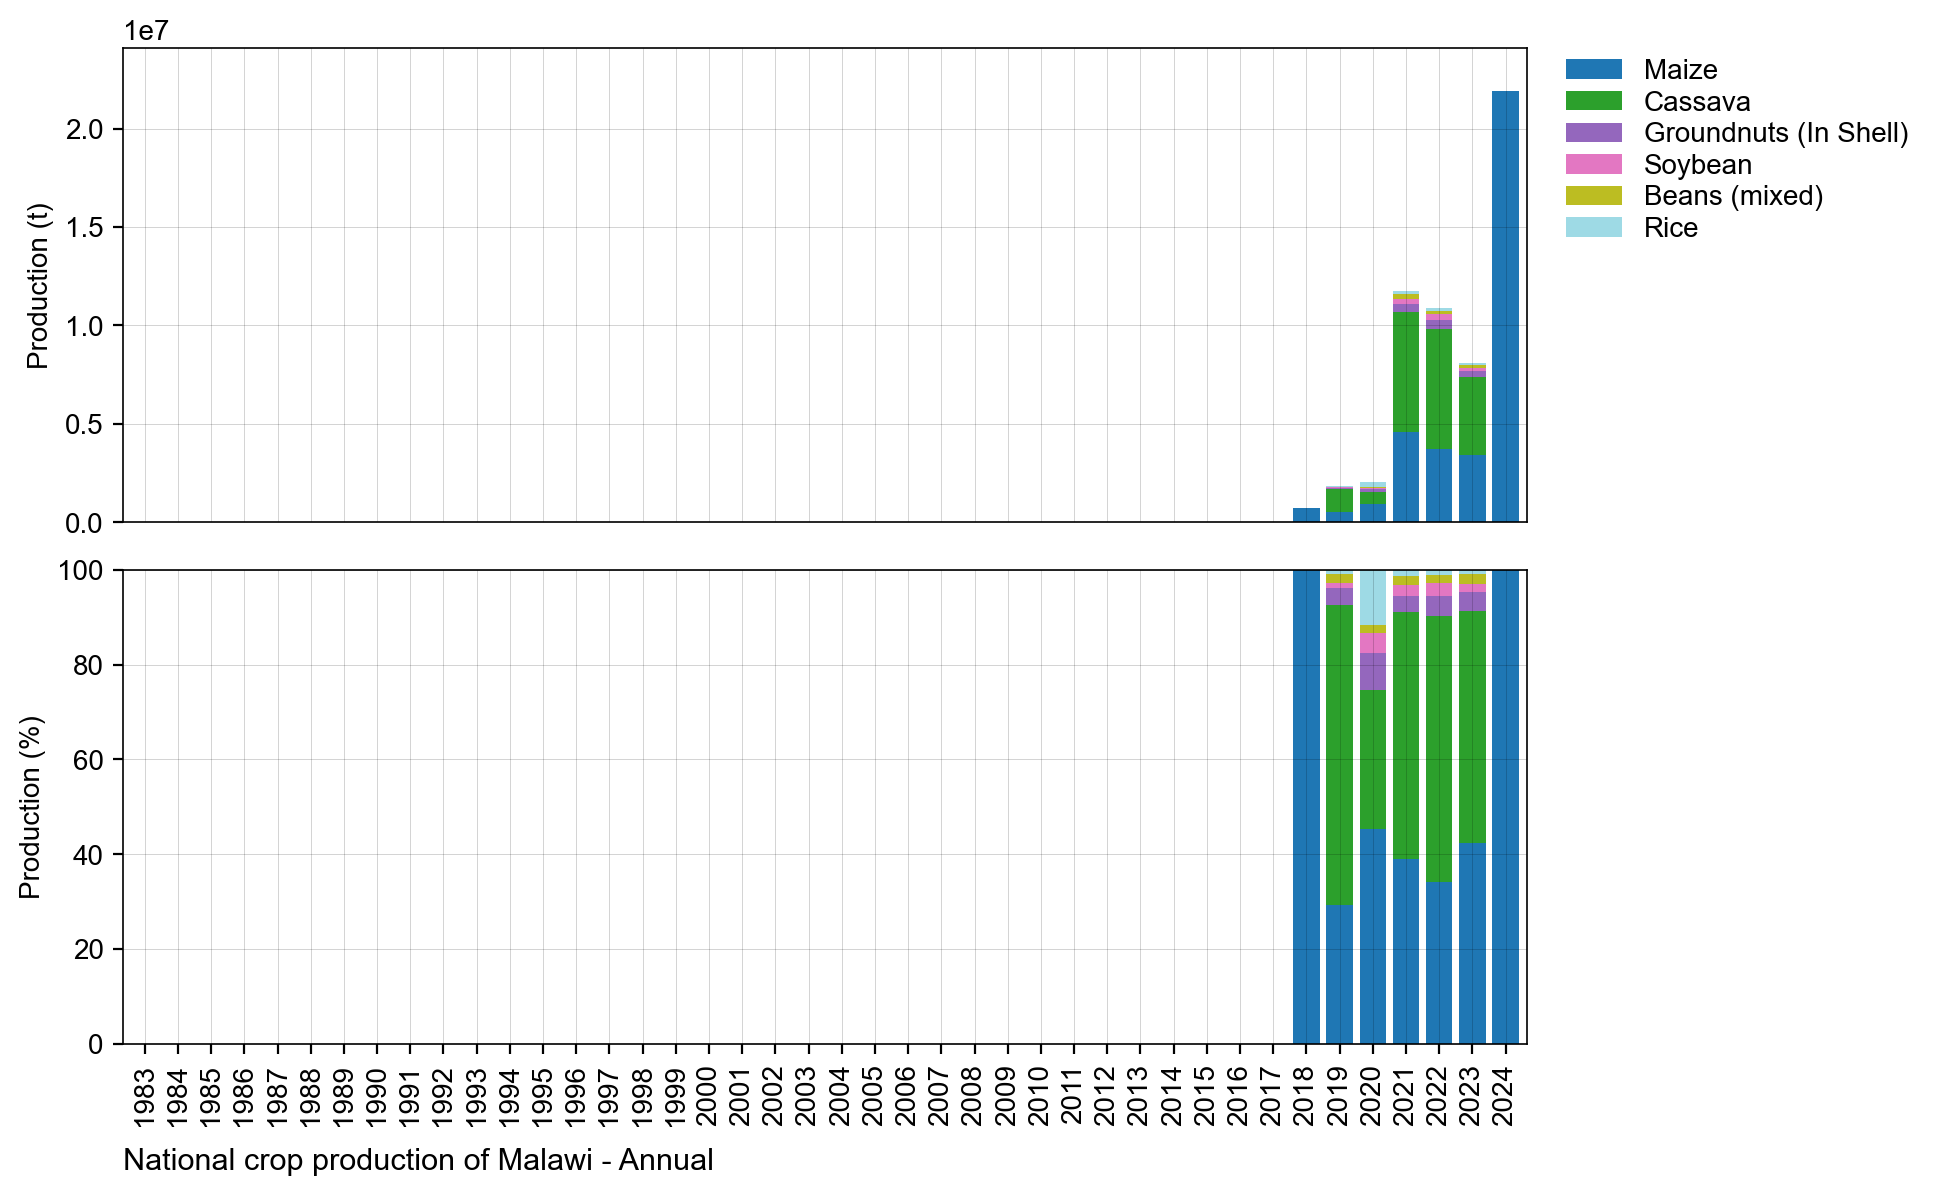

../figures/MW_bar_natgrainprod_Annual.png is saved.


/Users/weston/Documents/Code/Project/HarvestStat/HarvestStat/notebook/tools_graphic.py:135: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  axes[1].grid(which='minor', axis='x', linestyle='-', color='black', visible=False)


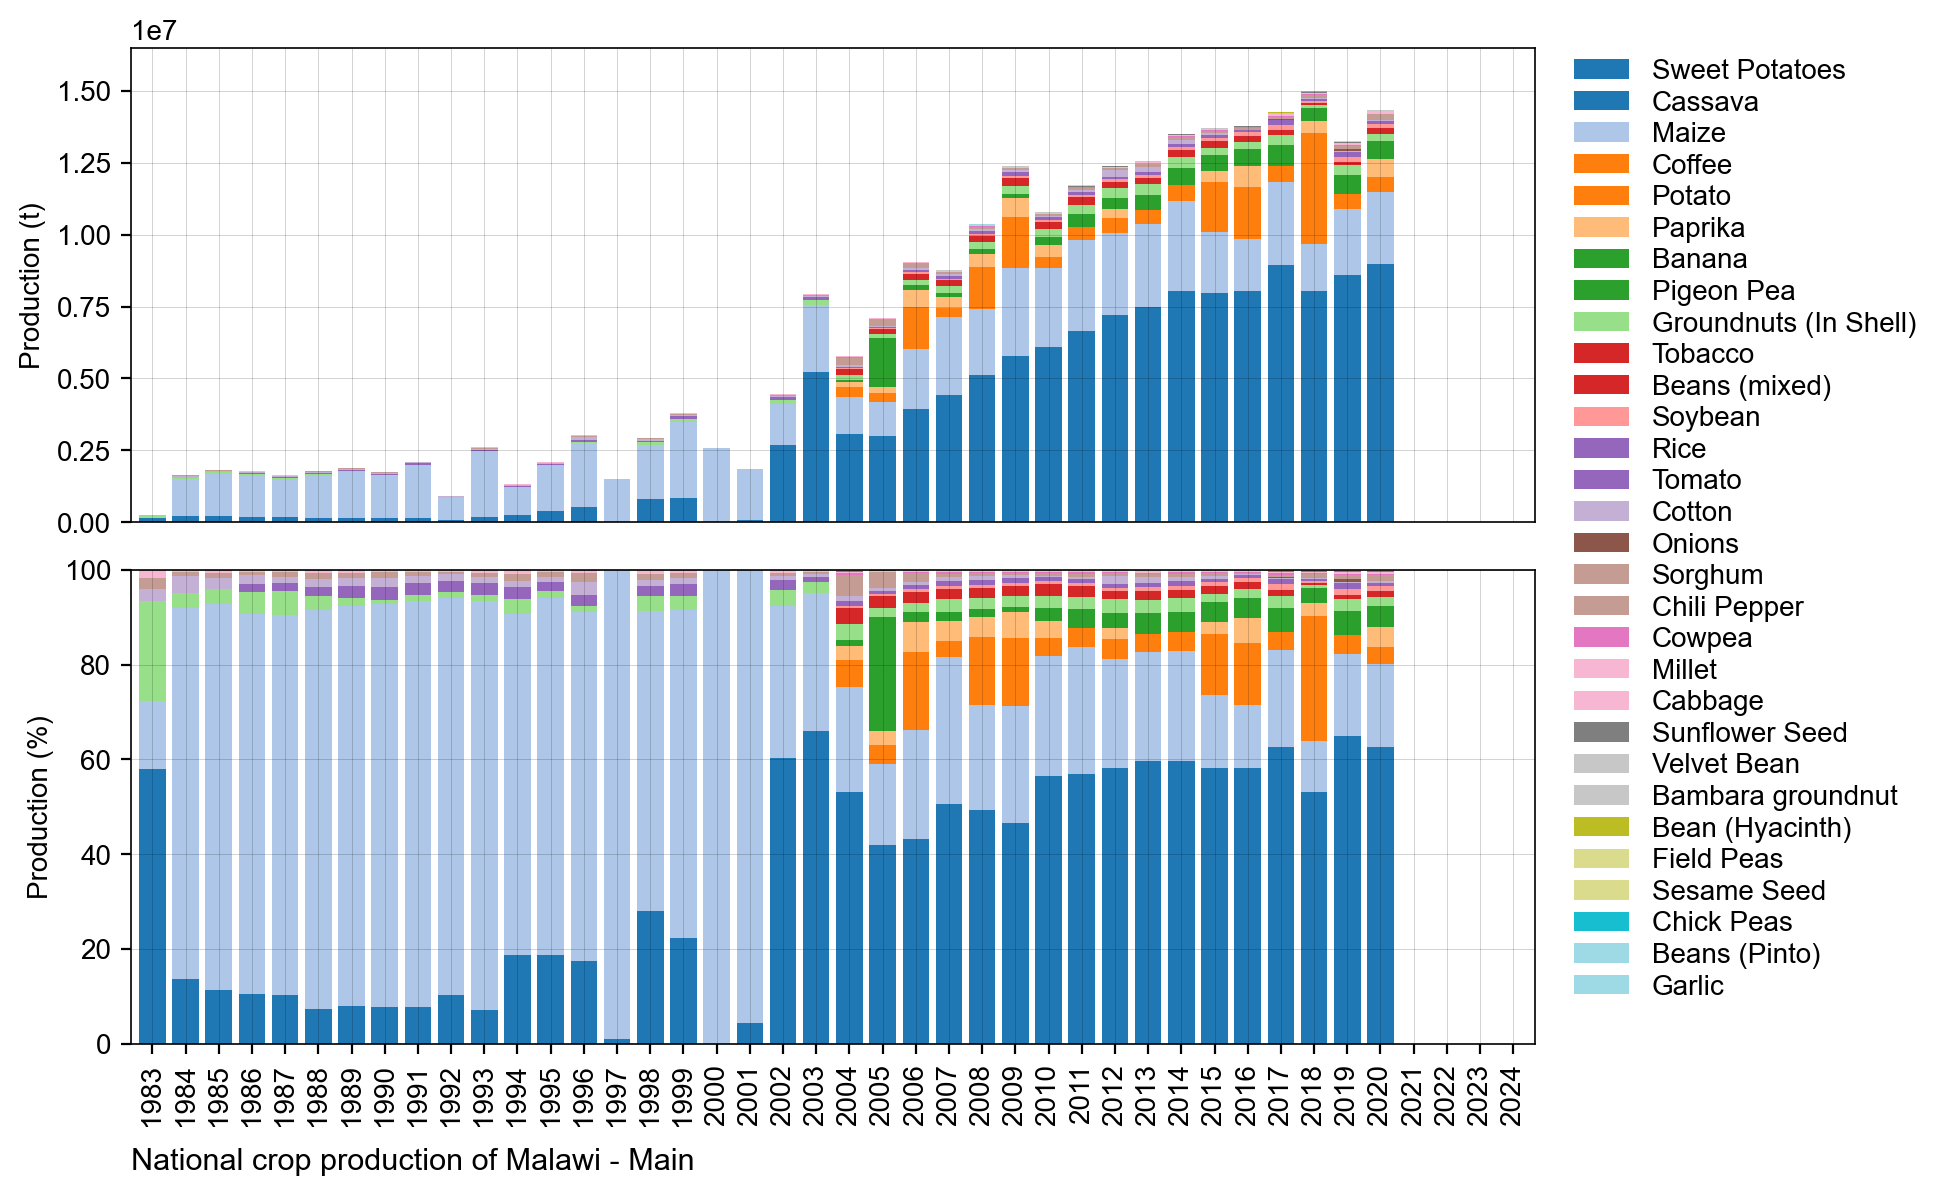

../figures/MW_bar_natgrainprod_Main.png is saved.


/Users/weston/Documents/Code/Project/HarvestStat/HarvestStat/notebook/tools_graphic.py:135: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  axes[1].grid(which='minor', axis='x', linestyle='-', color='black', visible=False)


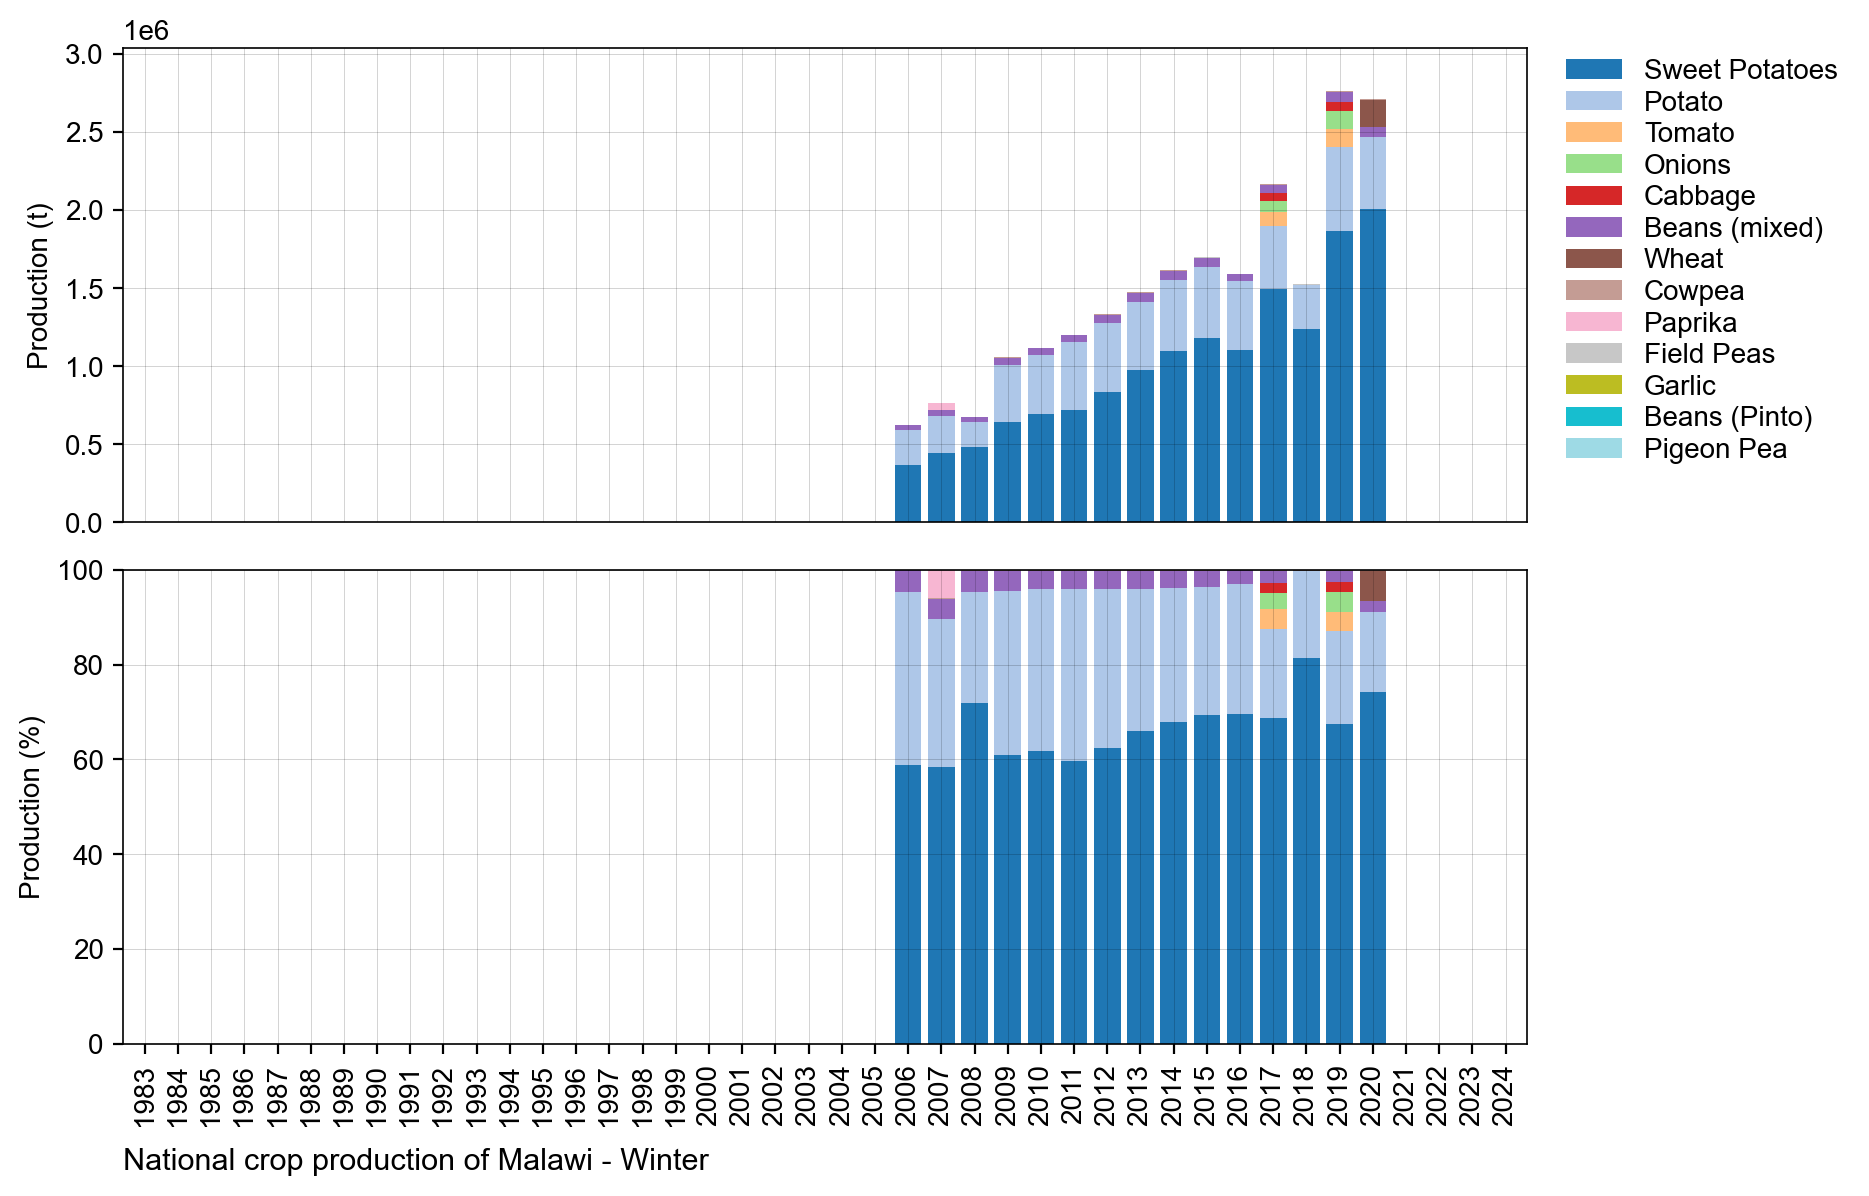

../figures/MW_bar_natgrainprod_Winter.png is saved.


In [8]:
# Bar chart of national grain production
country_iso, country_name = 'MW', 'Malawi'
df = pd.read_csv('../data/crop/adm_crop_production_%s.csv' % country_iso)
df['year'] = df['harvest_year']
year = [df['year'].min(), df['year'].max()]
for season_name in ['Annual','Main','Winter']:
    footnote = 'National crop production of %s - %s' % (country_name, season_name)
    fn_save = '../figures/%s_bar_natgrainprod_%s.png' % (country_iso, season_name)
    sub = df[df['season_name'] == season_name]
    PlotBarProduction(sub, year, footnote, fn_save)

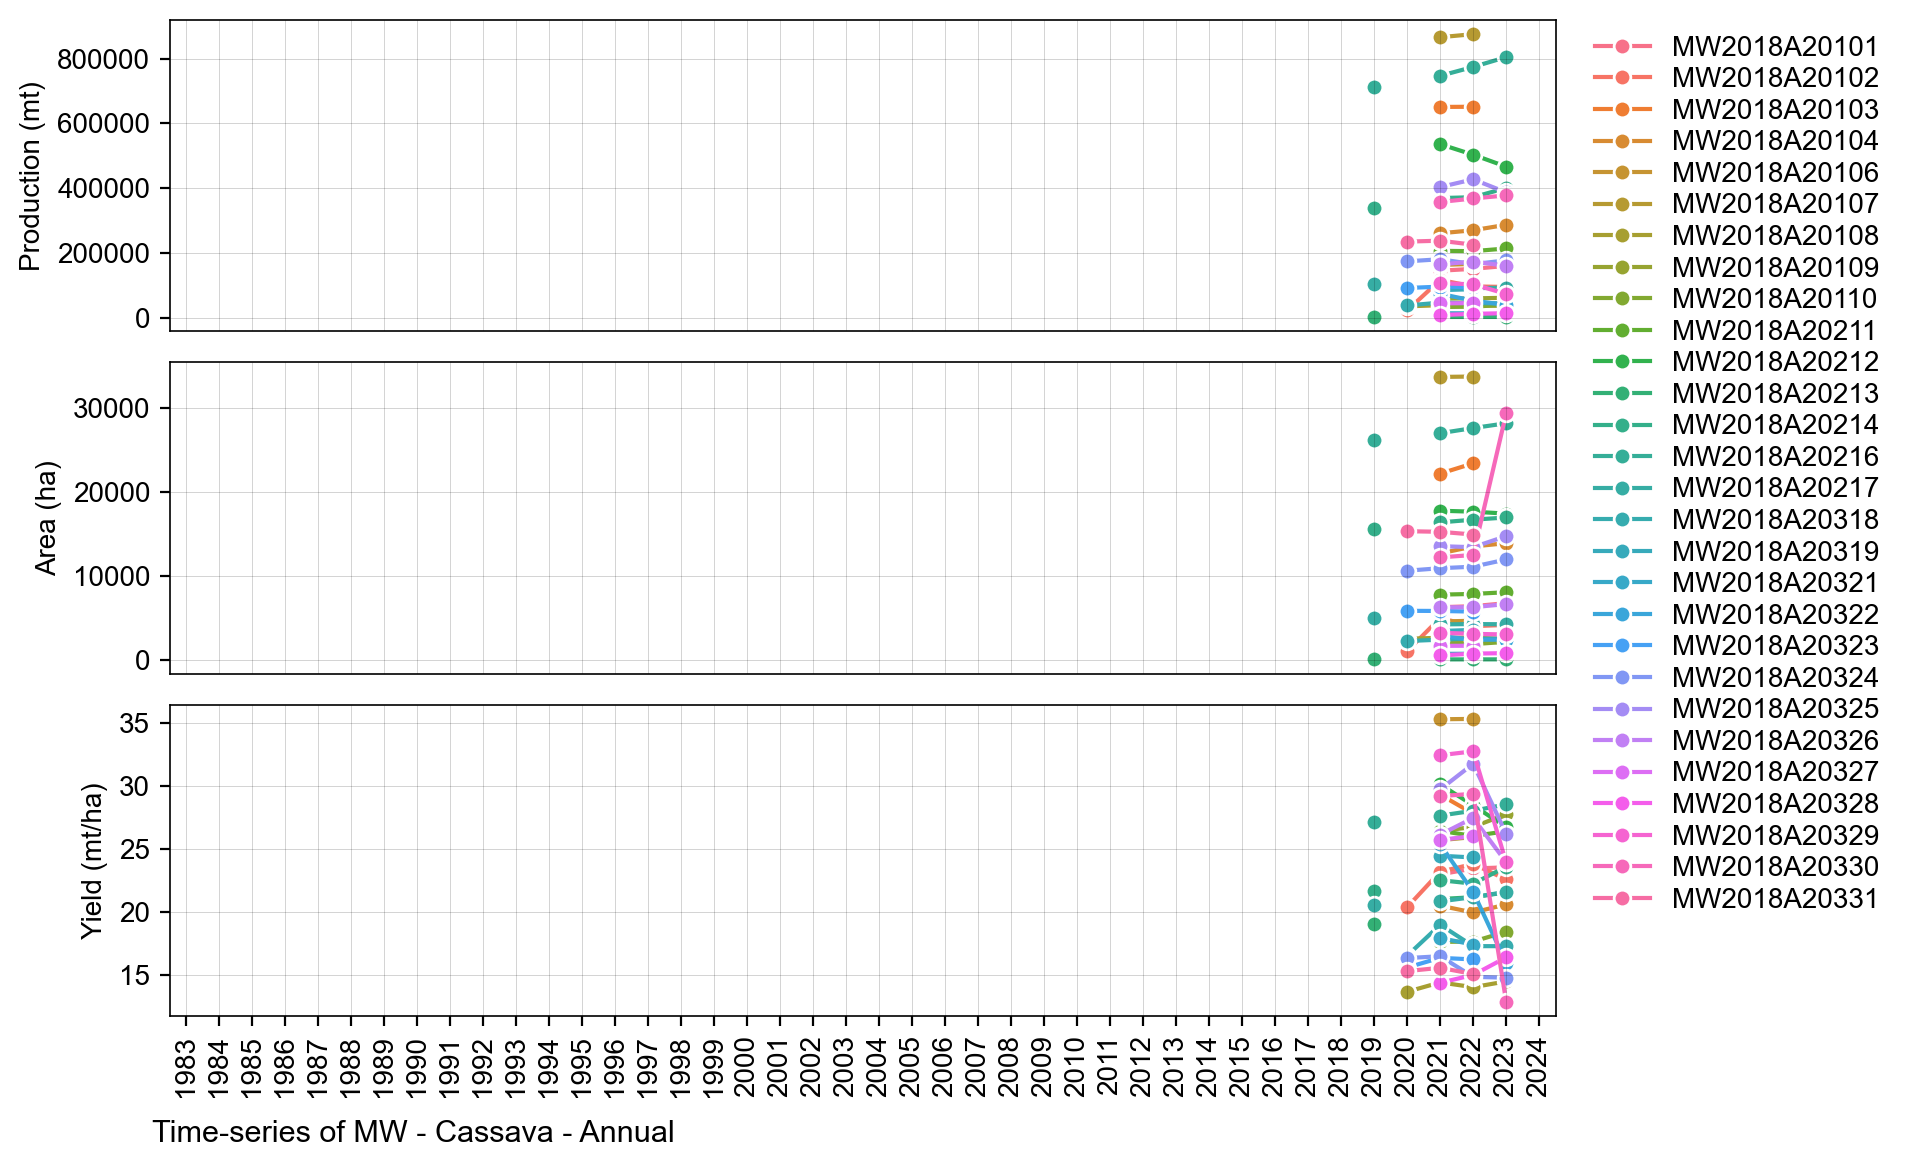

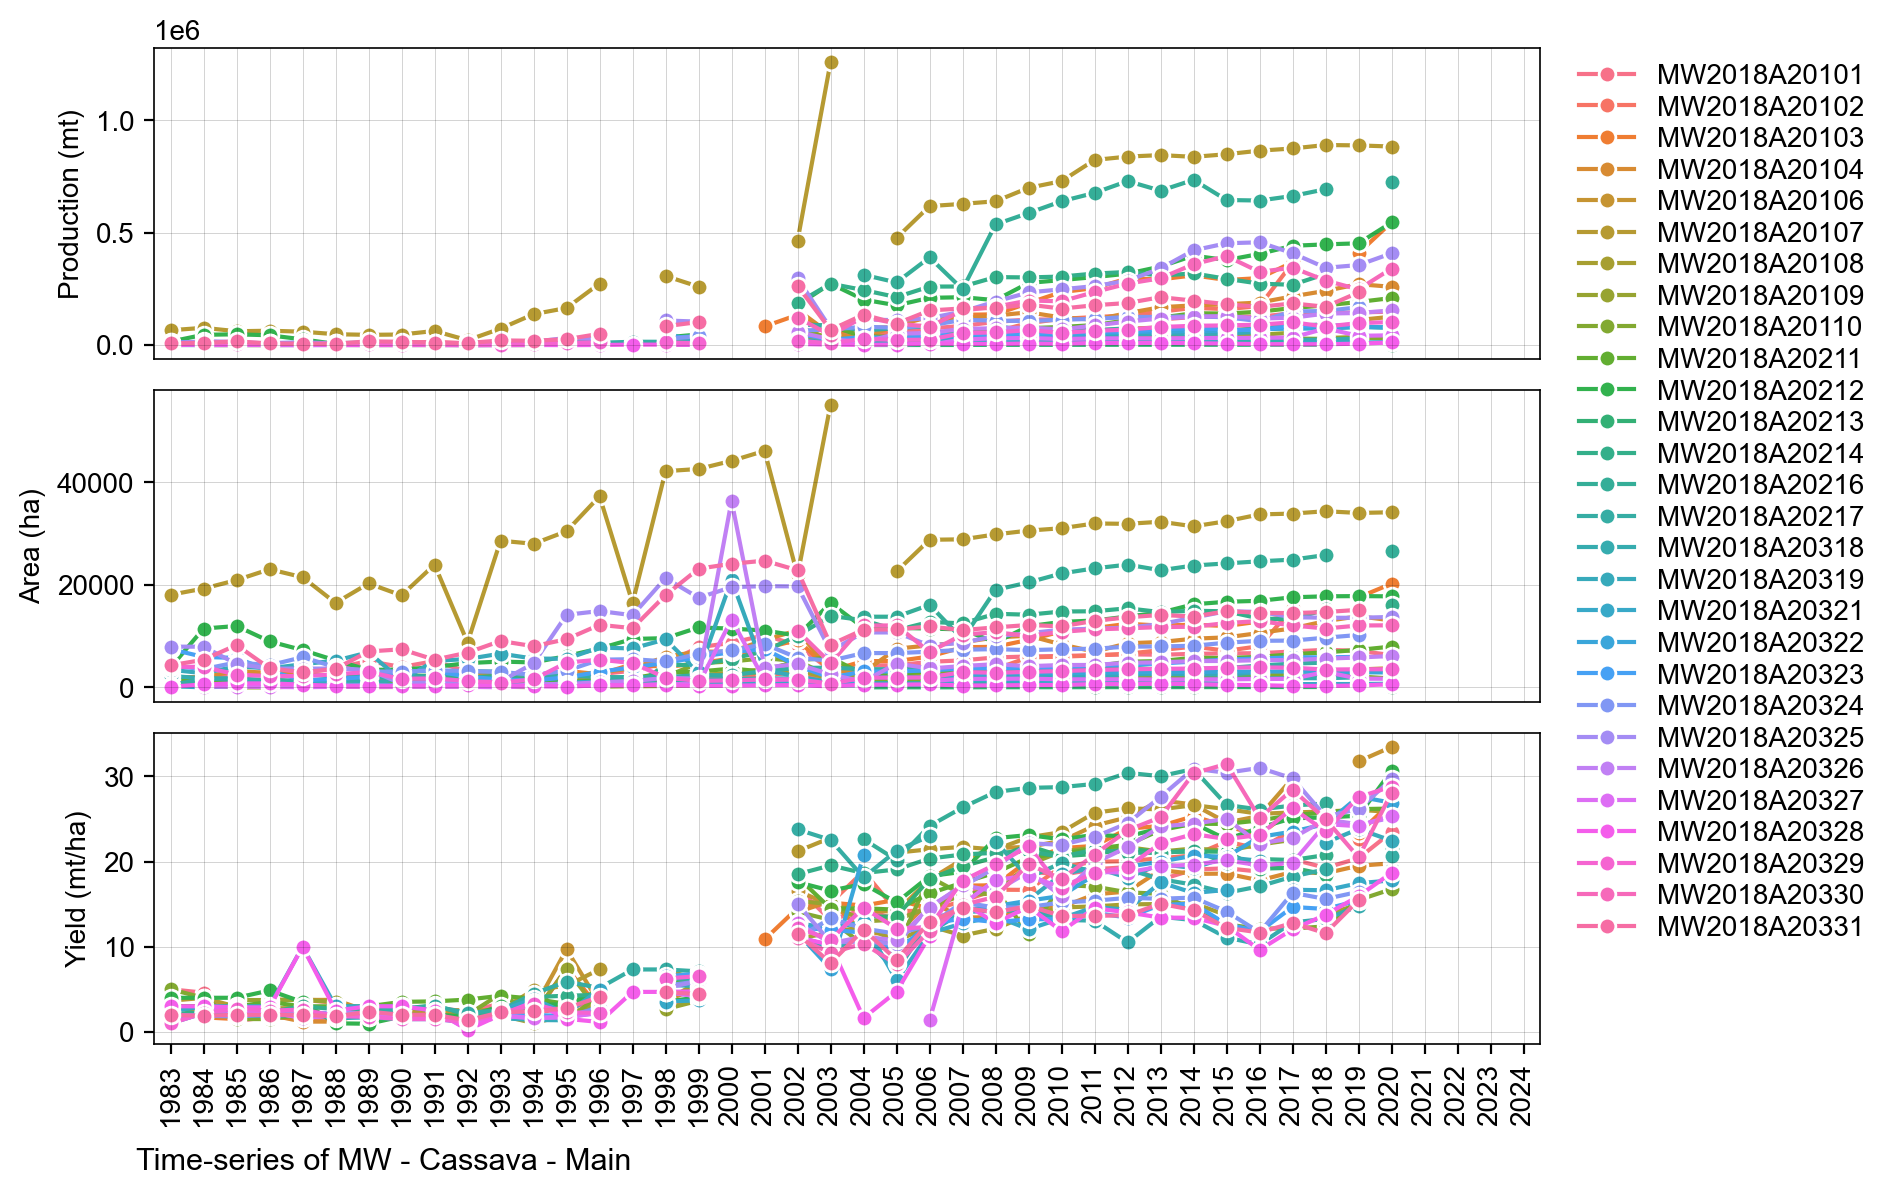

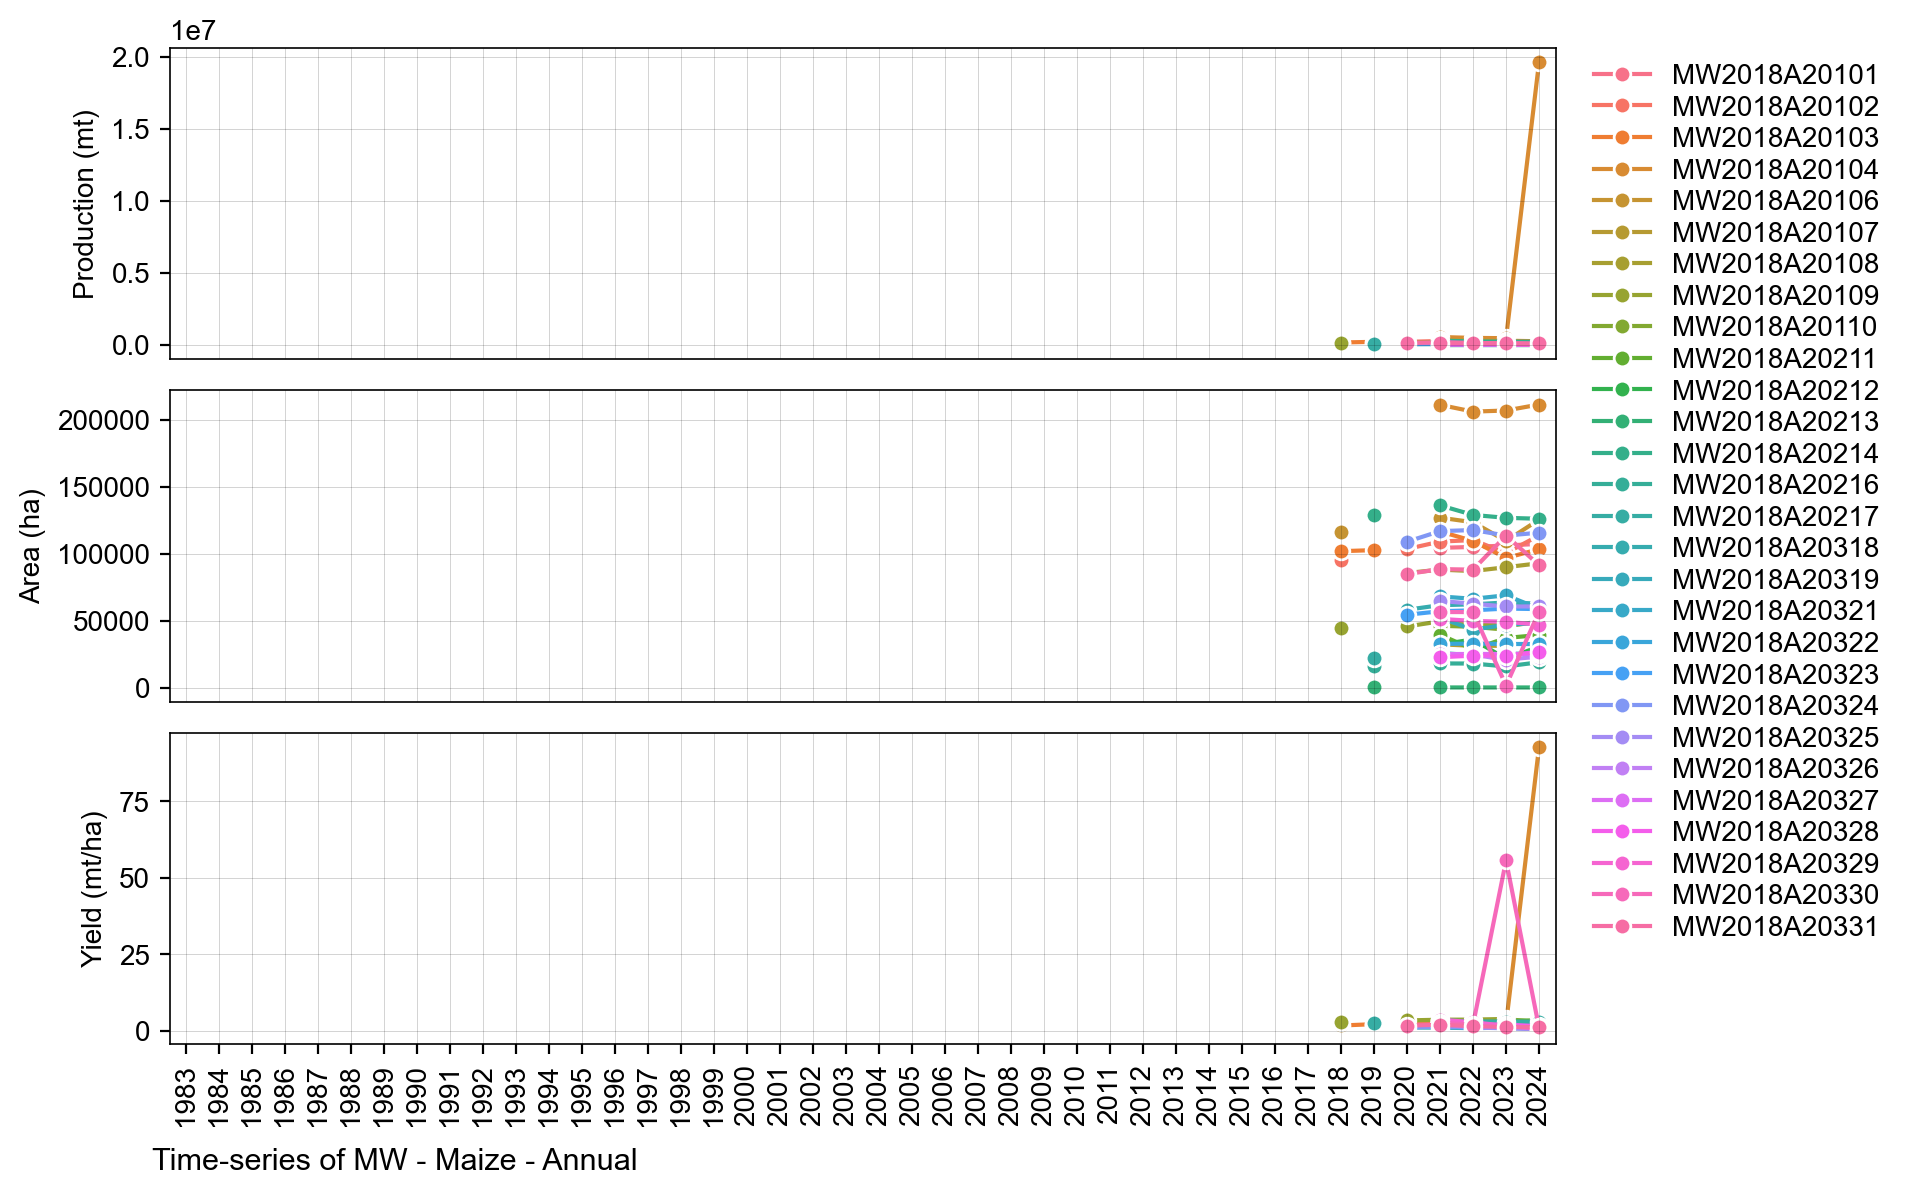

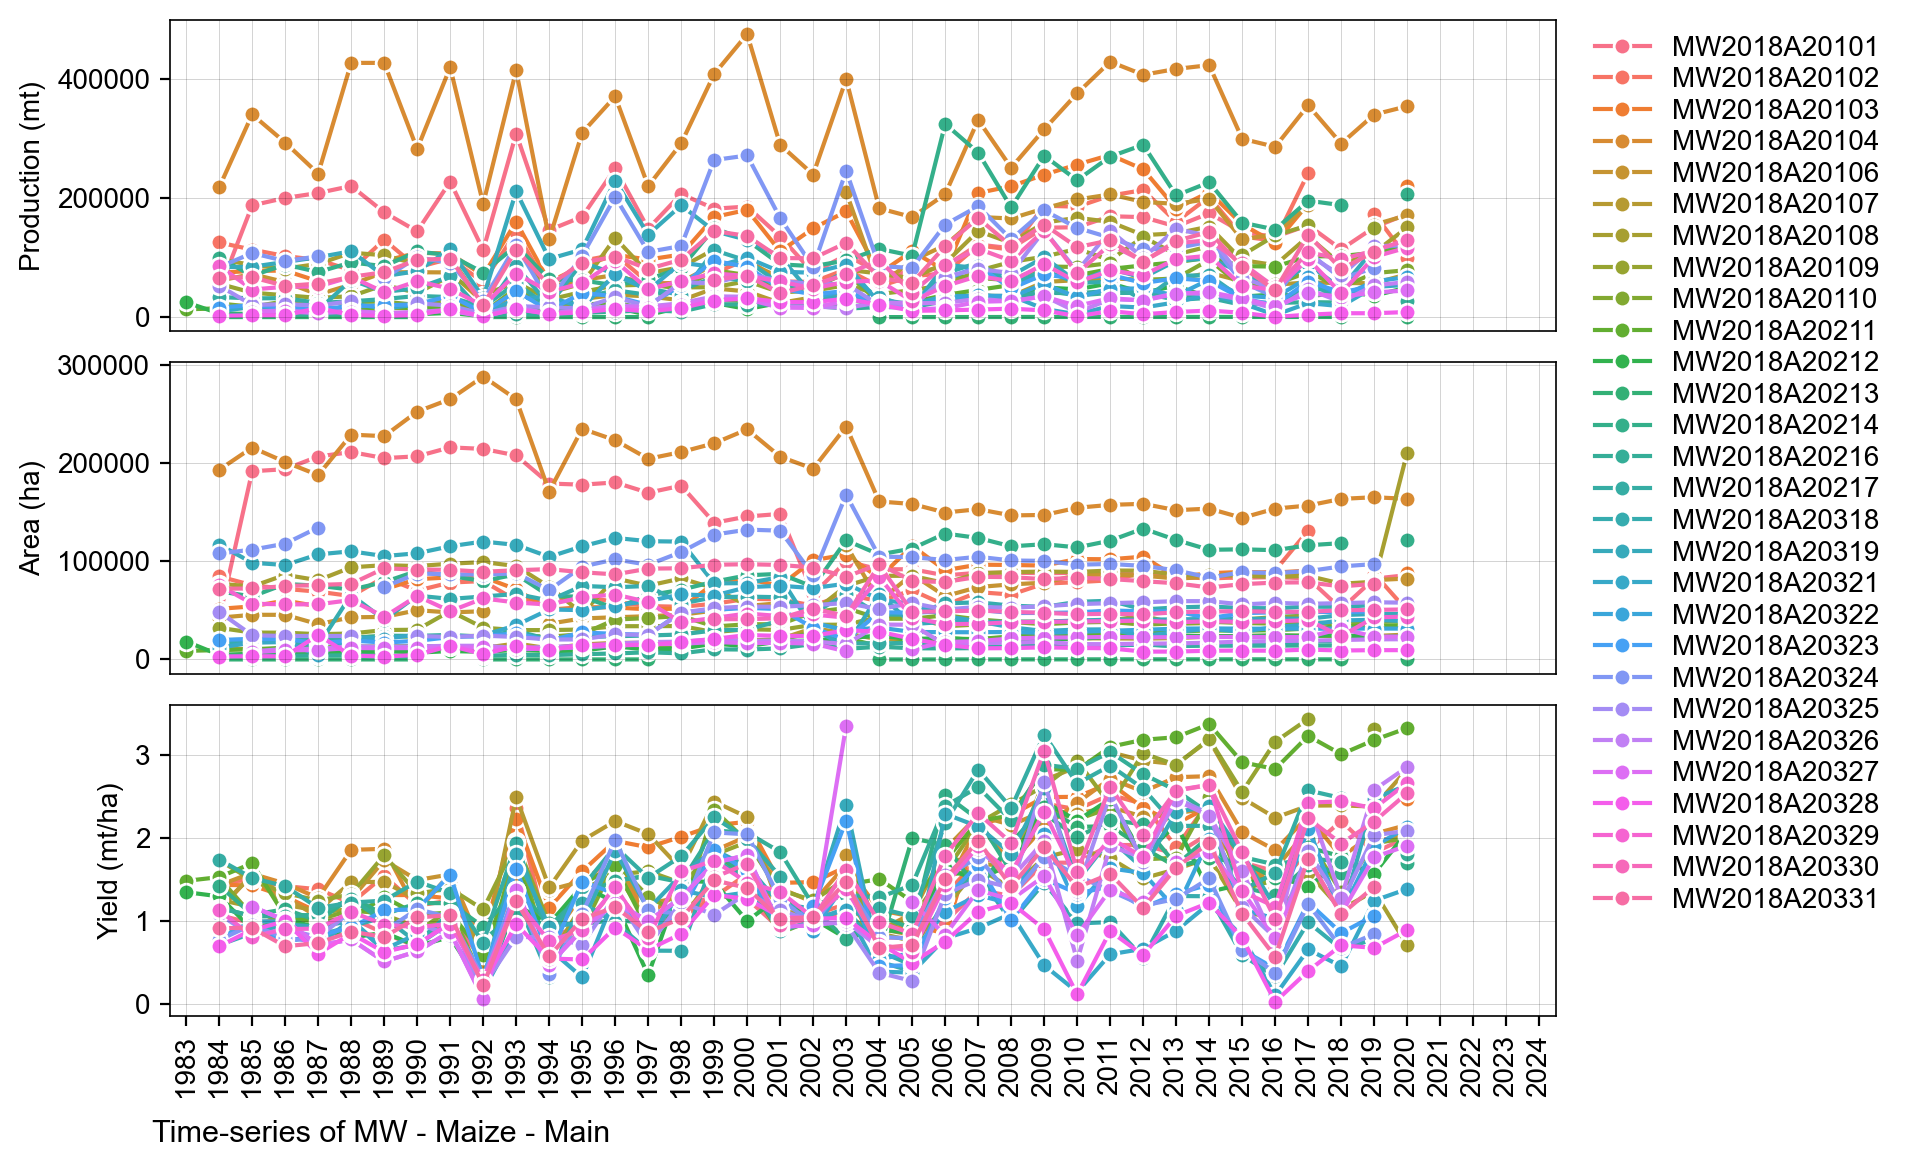

In [9]:
# Lineplot of Production-Area-Yield (PAY) time-series
country_iso, country_name = 'MW', 'Malawi'
df = pd.read_csv('../data/crop/adm_crop_production_%s.csv' % country_iso)
df['year'] = df['harvest_year']
year = [df['year'].min(), df['year'].max()]
product_season = [
    ['Cassava','Annual'],
    ['Cassava','Main'],
    ['Maize','Annual'],
    ['Maize','Main'],
]
for product_name, season_name in product_season:
    footnote = 'Time-series of %s - %s - %s' % (country_iso, product_name, season_name)
    fn_save = '../figures/%s_line_pay_%s_%s.png' % (country_iso, product_name, season_name)
    sub = df[(df['product'] == product_name) & (df['season_name'] == season_name)]
    PlotLinePAY(sub, year, footnote)